In [1]:
import torch
import matplotlib.pyplot as plt
from core.training import train_tise
from tise1d.tise1d import Loss_PDE, Loss_Orthogonality, PotentialHarmonicOscillator, ansatzfactor_HO_sym

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
torch.manual_seed(124)

In [4]:
# DEFINE DATASET
x_lim = (-3.0, 3.0) # Box

N_samples = 256
x = torch.rand(N_samples, 1)*(x_lim[1]-x_lim[0])+x_lim[0]

In [5]:
from scipy.special import hermite,factorial
import numpy as np

def psi_analytic(x, L = None, n=1):
    hbar = 1
    m = 1
    omega = 1
    x = x.numpy()
    return torch.tensor((1/(np.sqrt((2**n)*factorial(n))*np.pi**0.25))*np.exp(-x**2/2)*hermite(n)(x))

def energy_analytic(L=None,n=1):
    hbar = 1
    omega = 1
    return (n + 0.5)

def compare_analytic(x, pinn, n=1):
    with torch.no_grad():
        psi_pred = pinn(x.to(device)).cpu()
    psi_exact = psi_analytic(x,x[-1], n).cpu()

    overlap = torch.sum(psi_pred*psi_exact) 

    if overlap < 0: 
        psi_pred = -psi_pred

    energy_pred =  pinn.E
    energy_exact = energy_analytic(x[-1], n)
    rel_error = torch.abs((energy_pred - energy_exact) / energy_exact)
    print(f"Predicted Energy: {energy_pred.item():.6f}, Exact Energy: {energy_exact:.6f}, Relative Error: {rel_error:.6%}")
    
    
    plt.plot(x.numpy(), psi_pred.numpy()/torch.sqrt(((x[-1] - x[0])*torch.mean(psi_pred**2))), label='PINN Prediction')
    plt.plot(x.numpy(), psi_exact.numpy(), label='Analytic Solution', linestyle='dashed')
    plt.xlabel('x')
    plt.ylabel('ψ(x)')
    plt.title('Comparison of PINN and Analytic Solution')
    plt.legend()
    plt.show()

In [6]:
pinn1 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()),
    x_lim=x_lim,
    batch_size = 256,
    lr = 5e-2,
    lr_energy=1e-1,
    E_init = 0.1,
    ansatz_factor=ansatzfactor_HO_sym,
)

In [7]:
# Freeze
pinn1.eval()  # freeze behavior
for p in pinn1.parameters():
    p.requires_grad_(False)  

Predicted Energy: 0.500000, Exact Energy: 0.500000, Relative Error: 0.000072%


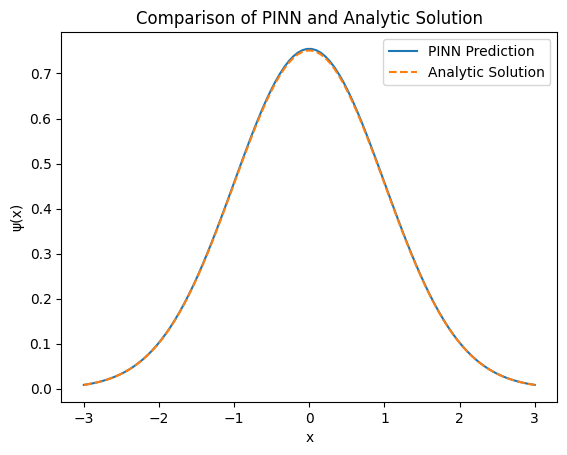

In [8]:
x_test = torch.linspace(x_lim[0], x_lim[1], 100).view(-1, 1).to(device)
compare_analytic(x_test,pinn1,n=0)

In [ ]:
pinn2 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 2000*Loss_Orthogonality([pinn1]),
    x_lim=x_lim,
    batch_size = 256,
    lr = 2e-3,
    lr_energy=1e-2,
    E_init = 0.5,
    ansatz_factor=ansatzfactor_HO_sym,
)

In [22]:
# Freeze
pinn2.eval()  # freeze behavior
for p in pinn2.parameters():
    p.requires_grad_(False)

Predicted Energy: 1.525448, Exact Energy: 1.500000, Relative Error: 1.696555%


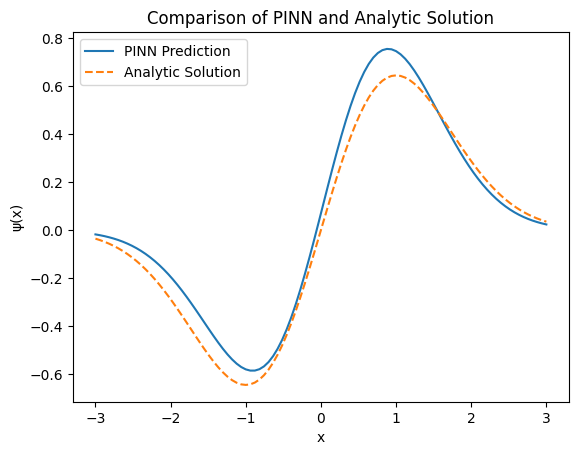

In [23]:
x_test = torch.linspace(x_lim[0], x_lim[1], 100).view(-1, 1).to(device)
compare_analytic(x_test, pinn2,n=1)